In [5]:
import pandas as pd
import numpy as np

import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.model_selection import cross_val_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer

In [6]:
df = pd.read_csv('train.csv',usecols=['Age', 'Fare','Survived'])

In [8]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [7]:
df['Age'].fillna(df['Age'].mean(),inplace=True)

/tmp/ipykernel_173/694922604.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].mean(),inplace=True)


In [9]:
df.head()

,Survived,Age,Fare
0,0,22.0,7.2500
1,1,38.0,71.2833
2,1,26.0,7.9250
3,1,35.0,53.1000
4,0,35.0,8.0500


In [10]:
X = df.iloc[:,1:3]
y = df.iloc[:,0]

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)

/tmp/ipykernel_173/2947286508.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Age'])


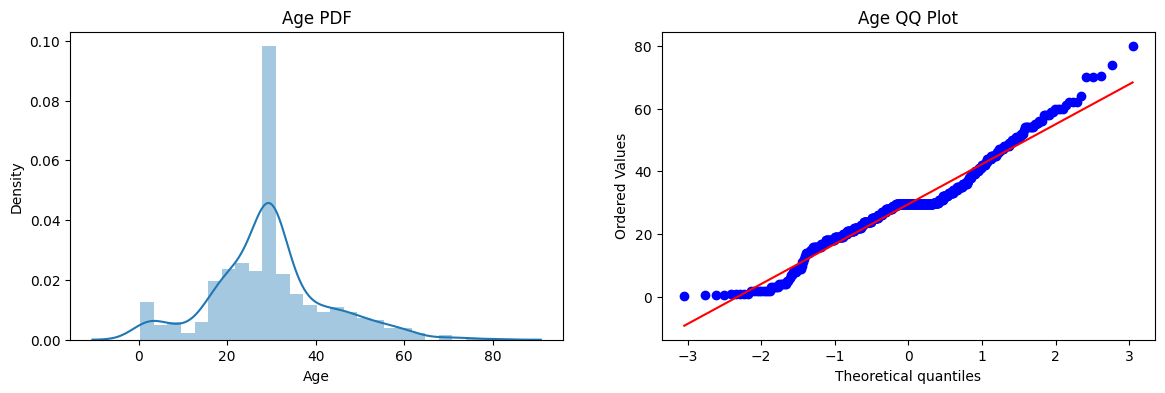

In [15]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.distplot(X_train['Age'])
plt.title('Age PDF')

plt.subplot(1,2,2)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age QQ Plot')

plt.show()



/tmp/ipykernel_173/4290434638.py:3: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(X_train['Fare'])


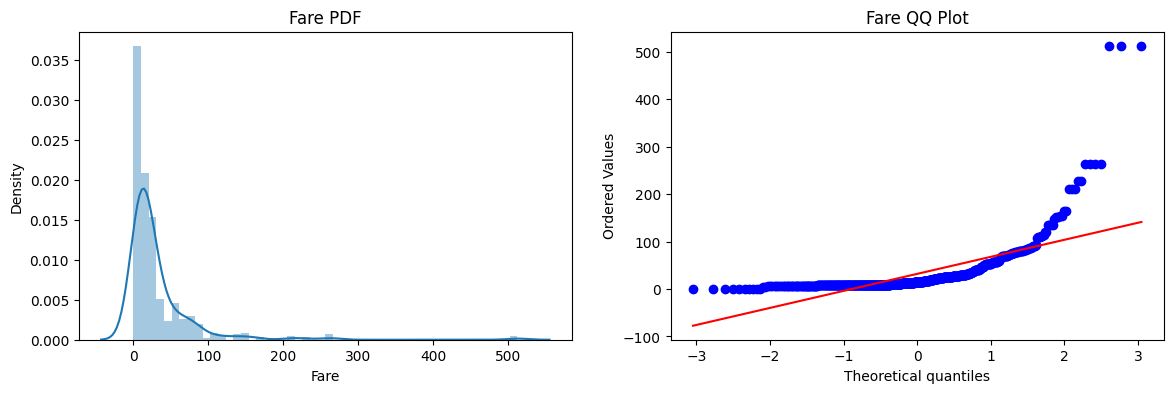

In [17]:
plt.figure(figsize=(14,4))
plt.subplot(1,2,1)
sns.distplot(X_train['Fare'])
plt.title('Fare PDF')

plt.subplot(1,2,2)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare QQ Plot')

plt.show()

In [18]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

In [22]:
clf.fit(X_train,y_train)
clf2.fit(X_train,y_train)

y_pred = clf.predict(X_test)
y_pred2 = clf2.predict(X_test)

print("Accuracy LR =",accuracy_score(y_test,y_pred))
print("Accuracy DT =",accuracy_score(y_test,y_pred2))

Accuracy LR = 0.6576271186440678
Accuracy DT = 0.6305084745762712


In [24]:
trf = FunctionTransformer(func=np.log1p)

In [25]:
X_train_transformed = trf.fit_transform(X_train)
X_test_transformed = trf.transform(X_test)

In [27]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

print("Accuracy LR =",accuracy_score(y_test,y_pred))
print("Accuracy DT =",accuracy_score(y_test,y_pred2))

Accuracy LR = 0.6847457627118644
Accuracy DT = 0.6305084745762712


In [30]:
X_transformed = trf.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.678027465667915
DT 0.6611111111111112


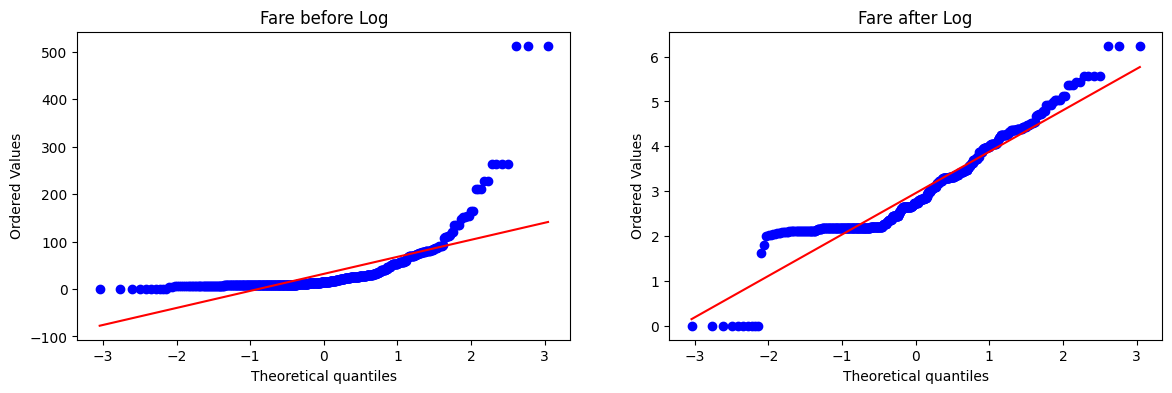

In [36]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(X_train['Fare'], dist="norm", plot=plt)
plt.title('Fare before Log')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Fare'], dist="norm", plot=plt)
plt.title('Fare after Log')

plt.show()

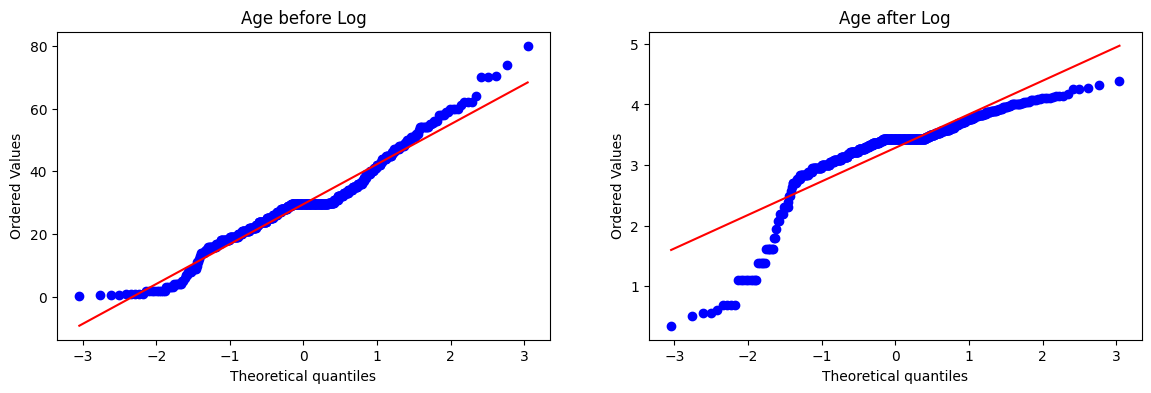

In [37]:
plt.figure(figsize=(14,4))

plt.subplot(1,2,1)
stats.probplot(X_train['Age'], dist="norm", plot=plt)
plt.title('Age before Log')

plt.subplot(1,2,2)
stats.probplot(X_train_transformed['Age'], dist="norm", plot=plt)
plt.title('Age after Log')

plt.show()

In [38]:
trf2 = ColumnTransformer([
    ('log',FunctionTransformer(func=np.log1p),['Fare'])], remainder='passthrough')

X_train_transformed = trf2.fit_transform(X_train)
X_test_transformed = trf2.transform(X_test)

In [40]:
clf = LogisticRegression()
clf2 = DecisionTreeClassifier()

clf.fit(X_train_transformed,y_train)
clf2.fit(X_train_transformed,y_train)

y_pred = clf.predict(X_test_transformed)
y_pred2 = clf2.predict(X_test_transformed)

print("Accuracy LR =",accuracy_score(y_test,y_pred))
print("Accuracy DT =",accuracy_score(y_test,y_pred2))

Accuracy LR = 0.6711864406779661
Accuracy DT = 0.6474576271186441


In [42]:
from sklearn.ensemble import RandomForestClassifier

X_transformed = trf2.fit_transform(X)

clf = LogisticRegression()
clf2 = DecisionTreeClassifier()
clf3 = RandomForestClassifier()

print("LR",np.mean(cross_val_score(clf,X_transformed,y,scoring='accuracy',cv=10)))
print("DT",np.mean(cross_val_score(clf2,X_transformed,y,scoring='accuracy',cv=10)))

LR 0.6712609238451936
DT 0.6667041198501873


In [43]:
def apply_transform(transform):
  x = df.iloc[:,1:3]
  y = df.iloc[:,0]

  trf = ColumnTransformer([
    ('log',transform,['Fare'])], remainder='passthrough')

  X_trans = trf.fit_transform(x)

  clf = LogisticRegression()

  print("Accuracy", np.mean(cross_val_score(clf,X_trans,y,scoring='accuracy',cv=10)))

  plt.figure(figsize=(14,4))

  plt.subplot(1,2,1)
  stats.probplot(x['Fare'], dist="norm", plot=plt)
  plt.title('Fare before Transform')

  plt.subplot(1,2,2)
  stats.probplot(X_trans[:,0], dist="norm", plot=plt)
  plt.title('Fare after Transform')

  plt.show()

Accuracy 0.6589013732833957


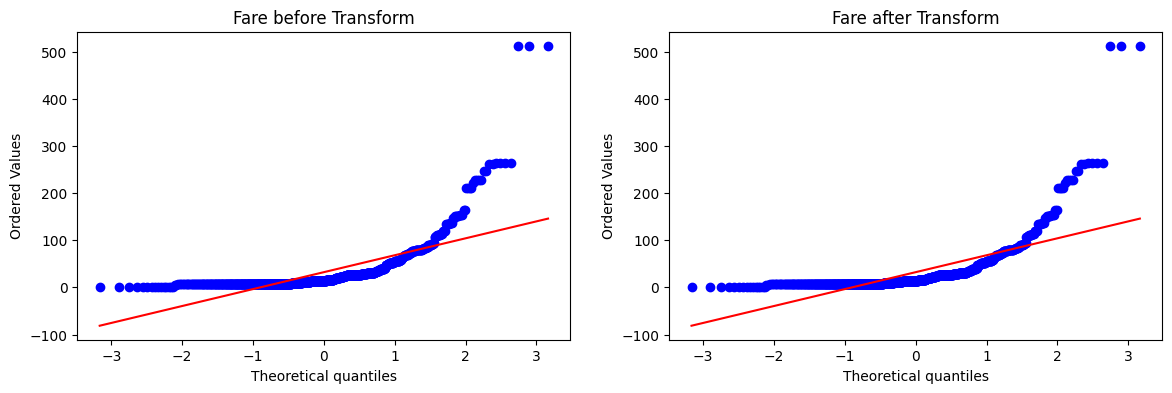

In [45]:
apply_transform(FunctionTransformer(func=lambda x: x))

Accuracy 0.6431335830212235


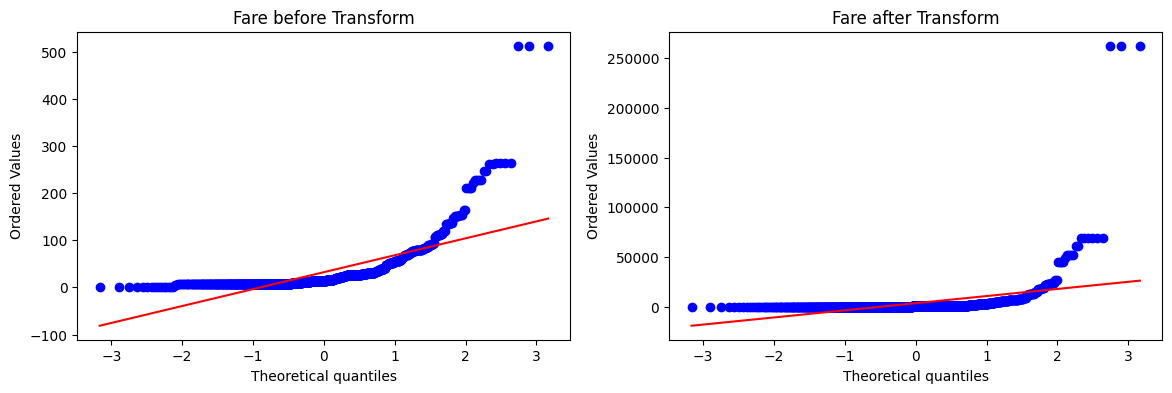

In [47]:
apply_transform(FunctionTransformer(func=lambda x: x**2))

Accuracy 0.6589013732833957


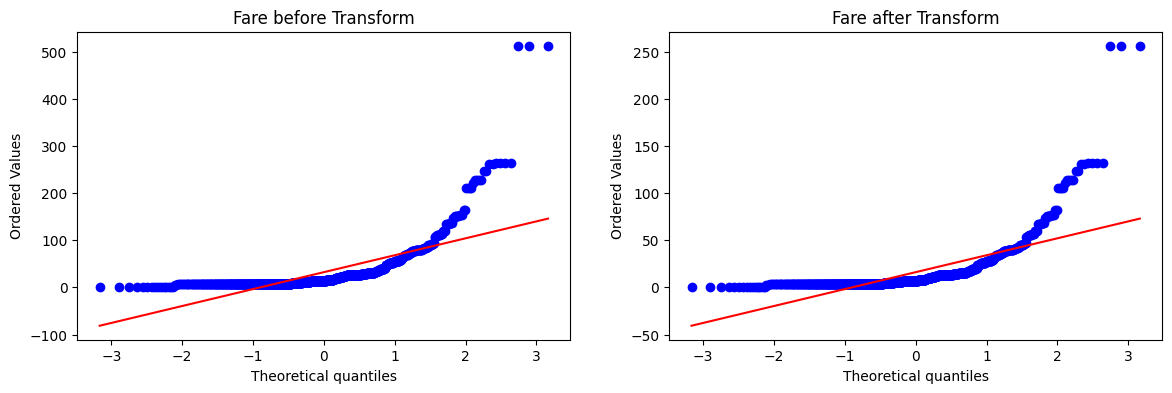

In [48]:
apply_transform(FunctionTransformer(func=lambda x: x**1/2))


Accuracy 0.616167290886392


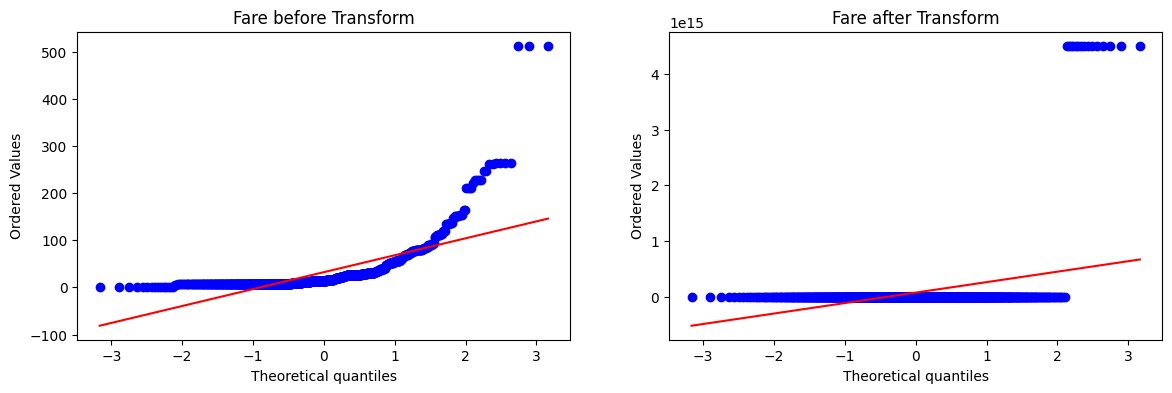

In [50]:
apply_transform(FunctionTransformer(func=lambda x: 1/(x + np.finfo(float).eps)))